Importing/Installing

In [ ]:
#1
# --- INSTALLATION ---
# Install Qiskit for working with quantum computers.
!pip install qiskit

In [ ]:
#2
# --- IMPORTS ---
import numpy as np # For numerical operations
import pandas as pd # For handling the MNIST dataset
import matplotlib.pyplot as plt # For plotting graphs and images
from sklearn.preprocessing import StandardScaler, MinMaxScaler # For data scaling
from sklearn.decomposition import PCA # For reducing the size of our images
from qiskit import QuantumCircuit # To build quantum circuits
from qiskit.circuit import Parameter # To create variables within our circuits

PCA







First, we read  sanitise the data

In [ ]:
#3
#Use all numbers from dataset
# Use the built-in Colab sample MNIST dataset.
#d0 = pd.read_csv("sample_data/mnist_train_small.csv", header=None)

#
#d0.rename(columns={0: "label"}, inplace=True)

#labels = d0["label"]
#data = d0.drop("label", axis=1)

######################################

# Use only numbers 0 and 1 from the dataset
d0 = pd.read_csv("sample_data/mnist_train_small.csv", header=None)

d0.rename(columns={0: "label"}, inplace=True)

d0 = d0[(d0["label"] == 0) | (d0["label"] == 1)]

labels = d0["label"].values
data = d0.drop("label", axis=1)

Next, we perform the PCA, and a few additional transformations requried for a clean transform

In [ ]:
#4
# --- DATA PREPROCESSING ---
# Quantum computers have limited capacity, so we must simplify our images.

# 1. Scaling: Standardize the data so each pixel has a similar range.
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

# 2. PCA (Principal Component Analysis): This 'squashes' 784 pixels down to just 8 numbers.
# These 8 numbers represent the most important features of the image.
pca = PCA(8)
converted_data = pca.fit_transform(scaled_data)

# 3. Normalization: Quantum gates take angles between 0 and PI.
# We map the 8 PCA numbers into this specific range.
normalisation = MinMaxScaler(feature_range=(0, np.pi))
normalised_data = normalisation.fit_transform(converted_data)

ENCODING

In [ ]:
#6
# --- QUANTUM DATA ENCODING ---
# In quantum computing, we must translate classical numbers into 'quantum states'.
# We use 'Parameters' as variables that will hold the PCA data during the run.

p0 = Parameter('p0')
p1 = Parameter('p1')
p2 = Parameter('p2')
p3 = Parameter('p3')
p4 = Parameter('p4')
p5 = Parameter('p5')
p6 = Parameter('p6')
p7 = Parameter('p7')

# Create a Quantum Circuit with 8 qubits.
Quantum = QuantumCircuit(8)

# These 'ry' gates rotate the qubit's state based on our input data.
# This is called 'Angle Encoding' because the data becomes an angle of rotation.
Quantum.ry(p0, 0)
Quantum.ry(p1, 1)
Quantum.ry(p2, 2)
Quantum.ry(p3, 3)
Quantum.ry(p4, 4)
Quantum.ry(p5, 5)
Quantum.ry(p6, 6)
Quantum.ry(p7, 7)

ANSATZ

In [ ]:
#7
# --- THE QUANTUM NEURAL NETWORK (ANSATZ) ---
# This part of the circuit has 'theta' weights that the computer will learn,
# similar to how a classical neural network learns weights.

from qiskit.circuit import Parameter
from qiskit import QuantumCircuit

# We take the encoding circuit from before and prepare to add the 'learning' layers.
Quantum = Quantum.copy()

# We create 24 trainable parameters (3 layers * 8 qubits).
params = [Parameter(f'theta{i}') for i in range(24)]

def layer(qc, params, offset):
    # First, we apply rotations that the computer can tune (the weights).
    for i in range(8):
        qc.ry(params[offset + i], i)

    # Second, we use CNOT gates (cx) to 'entangle' the qubits.
    # Entanglement is a quantum property that lets qubits share information.
    for i in range(7):
        qc.cx(i, i+1)
    qc.cx(7, 0)

# We add 3 layers of this quantum 'brain' structure.
layer(Quantum, params, 0) # Layer 1
layer(Quantum, params, 8) # Layer 2
layer(Quantum, params, 16) # Layer 3

# At the end, we 'measure' the qubits to get a classical answer (0s and 1s).
Quantum.measure_all()

loop

In [ ]:
#8
# --- THE SAMPLER ---
# The 'Sampler' is a tool that runs our circuit multiple times and collects the results.
# Since quantum physics is probabilistic, we need to run it many times to see which answer is most common.
from qiskit.primitives import StatevectorSampler
sampler = StatevectorSampler()

In [ ]:
#9
# --- CALCULATING THE ERROR (COST FUNCTION) ---
# This function checks how close the quantum computer's guess is to the real label.

def cost_function(theta_val, image_index, target_val):
    # Get the specific data for the current image
    image_data = normalised_data[image_index]

    # Bind our classical data and current 'weight guesses' (theta) to the circuit
    param_dict = {
        p0: image_data[0],
        p1: image_data[1],
        p2: image_data[2],
        p3: image_data[3],
        p4: image_data[4],
        p5: image_data[5],
        p6: image_data[6],
        p7: image_data[7],
    }

    for i in range(24):
        param_dict[Quantum.parameters[8 + i]] = theta_val[i]

    # Execute the circuit on a quantum simulator
    bound = Quantum.assign_parameters(param_dict)
    result = sampler.run([bound]).result()
    counts = result[0].data.meas.get_counts()

    total = sum(counts.values())
    prob_0 = 0
    prob_1 = 0

    # We look at the output bits (like '01010101') and use their parity
    # (odd or even) to decide if the model thinks the image is a 0 or a 1.
    for bitstring, count in counts.items():
        label = int(bitstring, 2)
        class_id = label % 2 # Even = Class 0, Odd = Class 1

        if class_id == 0:
            prob_0 += count / total
        else:
            prob_1 += count / total

    # Calculate the 'loss'. If the target is 0, we want prob_0 to be high.
    if target_val == 0:
        return 1 - prob_0
    else:
        return 1 - prob_1

In [ ]:
#10
# --- TEST RUN ---
# Before training, we generate random 'theta' weights to see how the model performs by pure chance.
initial_theta = np.random.uniform(-np.pi, np.pi, 24)

image_idx = 1
target = labels[image_idx]

try:
    # We calculate the error (loss) for a single image with these random weights.
    current_loss = cost_function(initial_theta, image_idx, target)
    print(f"Current loss (with random weights) = {current_loss}")
except Exception as e:
    print(f"Error: {e}")

Current loss = 0.48828125


optimizer

In [ ]:
#11
# --- TRAINING THE MODEL ---
# The optimizer adjusts 'theta' to minimize error.
from scipy.optimize import minimize

# We pick a random subset (batch) of images to train on to save time.
training_batch = np.random.choice(len(labels), size=300, replace=False) #(Use 300 images or less for speed, or more to take longer but have better accuracy)

def optimization_wrapper(theta_guess):
    # For every image in our batch, calculate the error and find the average.
    batch_losses = []
    for idx in training_batch:
        target_val = labels[idx]
        loss = cost_function(theta_guess, idx, target_val)
        batch_losses.append(loss)
    return np.mean(batch_losses)

print(f"Starting optimization on {len(training_batch)} images...")
# 'minimize' works by finding the lowest error.
result = minimize(optimization_wrapper, initial_theta, method='COBYLA', options={'maxiter': 150})#(Use 150 Iterations or less for speed)

optimized_theta = result.x
print(f"New Best Theta: {optimized_theta}")

Starting optimization on 300 images...
New Best Theta: [ 1.03234537  3.14872733 -3.05829339 -1.68975906  0.034093    3.14375706
 -0.3793524  -1.0175635   2.23931422 -1.81272159 -2.9409948  -0.00665838
 -2.6957843  -1.49628811  0.07699987  1.53336915  3.0880541   1.69754929
 -3.11826965 -0.27009608  1.31244567  1.59412667  2.47698812  0.01375475]


In [ ]:
#12
# --- TESTING & EVALUATION ---
# Now we check how well our optimized weights work on the entire dataset.

def predict(theta_val, image_index):
    # Prepare the data and circuit
    image_data = normalised_data[image_index]

    param_dict = {
        p0: image_data[0],
        p1: image_data[1],
        p2: image_data[2],
        p3: image_data[3],
        p4: image_data[4],
        p5: image_data[5],
        p6: image_data[6],
        p7: image_data[7],
    }

    for i in range(24):
        param_dict[Quantum.parameters[8 + i]] = theta_val[i]

    bound = Quantum.assign_parameters(param_dict)
    result = sampler.run([bound]).result()
    counts = result[0].data.meas.get_counts()

    # Calculate probability for class 0 vs class 1
    total = sum(counts.values())

    prob_0 = 0
    prob_1 = 0

    for bitstring, count in counts.items():
        label = int(bitstring, 2)
        class_id = label % 2

        if class_id == 0:
            prob_0 += count / total
        else:
            prob_1 += count / total

    return 1 if prob_1 > prob_0 else 0

# Run the test on all images and track accuracy over time
correct = 0
total_tests = len(labels)
accuracies = []

print(f"--- Testing model on {total_tests} images ---")
for i in range(total_tests):
    p = predict(optimized_theta, i)
    if p == labels[i]:
        correct += 1
    accuracies.append((correct / (i + 1)) * 100)

    if (i + 1) % 50 == 0:
        print(f"Tested {i+1} images... Current Accuracy: {accuracies[-1]:.2f}%")

# Visualize the accuracy growth
plt.figure(figsize=(10, 5))
plt.plot(range(1, total_tests + 1), accuracies, label='Model Accuracy')
plt.xlabel('Images Tested')
plt.ylabel('Accuracy (%)')
plt.title('Quantum Model Performance')
plt.grid(True)
plt.show()

print("Final accuracy:", accuracies[-1])
#Higher accuracy if trained on more images + more max iterations or less amount of numbers

--- Testing model on 4205 images ---
50/4205 -> 100.00%
100/4205 -> 98.00%
150/4205 -> 98.00%
200/4205 -> 97.50%
250/4205 -> 96.80%
300/4205 -> 97.33%
350/4205 -> 97.14%
400/4205 -> 97.50%
450/4205 -> 97.56%
500/4205 -> 97.60%
550/4205 -> 97.64%
600/4205 -> 97.83%
650/4205 -> 97.69%
700/4205 -> 97.71%
750/4205 -> 97.73%
800/4205 -> 97.62%
850/4205 -> 97.65%
900/4205 -> 97.67%
950/4205 -> 97.68%
1000/4205 -> 97.70%
1050/4205 -> 97.81%
1100/4205 -> 97.91%
1150/4205 -> 97.91%
1200/4205 -> 97.92%
1250/4205 -> 97.92%
1300/4205 -> 97.92%
1350/4205 -> 97.70%
1400/4205 -> 97.79%
1450/4205 -> 97.79%
1500/4205 -> 97.87%
1550/4205 -> 97.94%
1600/4205 -> 97.94%
1650/4205 -> 97.94%
1700/4205 -> 97.94%
1750/4205 -> 97.94%
1800/4205 -> 98.00%
1850/4205 -> 98.05%
1900/4205 -> 98.11%
1950/4205 -> 98.10%
2000/4205 -> 98.05%
2050/4205 -> 98.10%
2100/4205 -> 98.14%
2150/4205 -> 98.14%
2200/4205 -> 98.14%
2250/4205 -> 98.18%
2300/4205 -> 98.22%
2350/4205 -> 98.21%
2400/4205 -> 98.21%
2450/4205 -> 98.24%
25

Model Prediction: 0
Confidence for 0: 72.7%


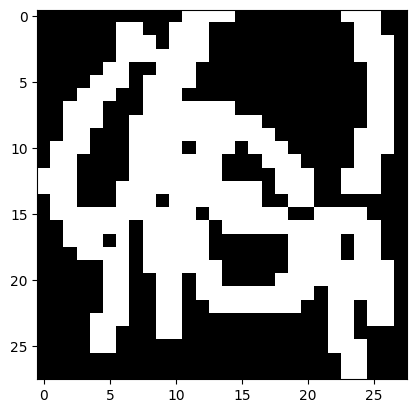

In [ ]:
# --- INTERACTIVE DRAWING CANVAS ---
# This section creates a canvas where you can draw digits to test the model in real-time.
# (Only works using 0 and 1 digits)

from IPython.display import HTML, display
from google.colab import output
import cv2
import numpy as np
from base64 import b64decode
import matplotlib.pyplot as plt

# The HTML/JavaScript below creates the UI for the drawing area and buttons
canvas_html = """
<style>
  @keyframes rainbow {
    0% { border-color: red; }
    15% { border-color: orange; }
    30% { border-color: yellow; }
    45% { border-color: green; }
    60% { border-color: blue; }
    75% { border-color: indigo; }
    90% { border-color: violet; }
    100% { border-color: red; }
  }
  #canv {
    border: 4px solid red;
    animation: rainbow 5s linear infinite;
    background: black;
    cursor: crosshair;
  }
</style>
<div style='display: flex; flex-direction: column; align-items: flex-start;'>
  <div id='status' style='margin-bottom: 5px; font-weight: bold; color: white; background: #333; padding: 2px 5px;'>Mode: Drawing (White)</div>
  <canvas id='canv' width='140' height='140'></canvas>
  <div>
    <button id='p' style='margin-top: 5px;'>Predict</button>
    <button id='c' style='margin-top: 5px;'>Clear</button>
    <button id='t' style='margin-top: 5px;'>Toggle Colour</button>
  </div>
</div>

<script>
  var canvas = document.getElementById('canv'), ctx = canvas.getContext('2d'), drawing = false;
  var statusLabel = document.getElementById('status');
  var isErasing = false;

  ctx.strokeStyle = 'white'; ctx.lineWidth = 10; ctx.lineCap = 'round';

  canvas.onmousedown = (e) => { drawing = true; ctx.beginPath(); ctx.moveTo(e.offsetX, e.offsetY); };
  canvas.onmousemove = (e) => { if (drawing) { ctx.lineTo(e.offsetX, e.offsetY); ctx.stroke(); } };
  canvas.onmouseup = () => { drawing = false; };

  document.getElementById('c').onclick = () => ctx.clearRect(0, 0, canvas.width, canvas.height);

  document.getElementById('t').onclick = () => {
    isErasing = !isErasing;
    if (isErasing) {
      ctx.strokeStyle = 'black';
      statusLabel.innerText = 'Mode: Erasing (Black)';
    } else {
      ctx.strokeStyle = 'white';
      statusLabel.innerText = 'Mode: Drawing (White)';
    }
  };

  document.getElementById('p').onclick = () => {
    google.colab.kernel.invokeFunction('notebook.Predict', [canvas.toDataURL('image/png')], {});
  };
</script>
"""

def do_predict(image_data):
    # 1. Decode the image you drew on the canvas
    binary = b64decode(image_data.split(',')[1])
    img = cv2.imdecode(np.frombuffer(binary, np.uint8), cv2.IMREAD_GRAYSCALE)
    img_resized = cv2.resize(img, (28, 28)) # Resize to match MNIST format (28x28)

    # 2. Apply the same preprocessing (Scale -> PCA -> Normalize)
    feat = normalisation.transform(pca.transform(scaler.transform(img_resized.reshape(1, -1))))[0]

    # 3. Feed the processed image into your Quantum Circuit
    p_dict = {p0:feat[0], p1:feat[1], p2:feat[2], p3:feat[3], p4:feat[4], p5:feat[5], p6:feat[6], p7:feat[7]}
    for i in range(24): p_dict[Quantum.parameters[8+i]] = optimized_theta[i]

    # 4. Run the quantum simulation and get the results
    res = sampler.run([Quantum.assign_parameters(p_dict)]).result()
    counts = res[0].data.meas.get_counts()

    # 5. Use the parity rule (Even=0, Odd=1) to determine the class
    c0 = sum(v for b,v in counts.items() if int(b,2)%2==0)
    total = sum(counts.values())

    output.clear(wait=True)
    display(HTML(canvas_html))
    print(f"Model Prediction: {0 if c0 > (total/2) else 1}")
    print(f"Confidence for 0: {(c0/total)*100:.1f}%")
    plt.imshow(img_resized, cmap='gray'); plt.show()

# Register the Python function so the JavaScript 'Predict' button can call it
output.register_callback('notebook.Predict', do_predict)
display(HTML(canvas_html))